In [1]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [2]:
frames_path = "dataset/frames/"
frames = os.listdir(frames_path)
model = torch.load("saved_models/ResNet50_decap.pt", map_location='cpu', weights_only=False)
json_data_path = "dataset/json_data/model_resnet.json"

In [3]:
def preprocess_image(image):
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return preprocess(image)


def extract_features(model, input_tensor):
    model.eval()
    with torch.no_grad():
        features = model(input_tensor)
    return features


def load_img(img_path, target_size=None):
    """
    Load and optionally resize an image
    """

    img = Image.open(img_path)
    if target_size:
        img = img.resize(target_size)
    return np.array(img)


def visualize_embeddings(embeddings, prune_mask=None):
    """
    Visualizes image embeddings, mainting their position even after pruning.
    
    Parameters:
    - embeddings: 2D numpy array
    - prune_mask: Boolean mask of shape (N,) indicating which images to keep
    """

    plt.figure(figsize=(10, 8))

    # Default keep all images
    if prune_mask is None:
        prune_mask = np.ones(len(embeddings), dtype=bool)
    
    # Apply mask to embeddings
    pruned_embeddings = embeddings[prune_mask]
    pruned_frames = np.array(frames)[prune_mask] # Keep only unpruned frames

    for idx, point in enumerate(pruned_embeddings):
        x, y = point[0], point[1]
        plt.scatter(x, y, alpha=0) # Invis scatter points to hold positions

        img_path = os.path.join(frames_path, pruned_frames[idx])
        img = load_img(img_path, target_size=(50, 50))
        imagebox = OffsetImage(img, zoom=0.8)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0.1)
        plt.gca().add_artist(ab)

    plt.title("Image Embeddings")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.autoscale(True)
    plt.grid()
    plt.show()

In [4]:
model_json_data = []
embeddings = []

for i, frame in enumerate(frames):
    img = Image.open(frames_path + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    features = extract_features(model, input_tensor)

    data = {
        "filename": f"frame{i}.jpg",
        "feature": features.cpu().numpy().flatten().tolist()
    }
    model_json_data.append(data)
    embeddings.append(features.cpu().numpy().flatten())

with open(json_data_path, 'w') as json_file:
    json.dump(model_json_data, json_file, indent=4)

embeddings = np.array(embeddings)

In [5]:
from sklearn.neighbors import NearestNeighbors

# Parameters
k = 5 # Number of nearest neighbors
prune = 30 # Percentage of lowest-entropy points to prune

# Fit kNN model on embeddings
nbrs = NearestNeighbors(n_neighbors=k).fit(embeddings)

# Calculate distances to k nearest neighbors
# Distances: array of shape (n_samples, k)
# _: indices of neighbors
distances, _ = nbrs.kneighbors(embeddings)

# Compute entropy using mean distance to neighbors
knn_entropies = np.log(np.mean(distances, axis=1))

# Compute overall entropy
entropy = np.mean(knn_entropies)
print(f"Initial entropy: {entropy}")

# Threshold for pruning
entropy_threshold = np.percentile(knn_entropies, prune)

# Indices of embeddings with entropy below threshold
prune_indices = np.where(knn_entropies <= entropy_threshold)[0]

# Create mask to retain high-entropy points
prune_mask = np.ones(len(embeddings), dtype=bool)
prune_mask[prune_indices] = False

# Fit kNN model on pruned embeddings
nbrs = NearestNeighbors(n_neighbors=k).fit(embeddings[prune_mask])

# Compute new kNN distances for pruned embeddings
distances,_ = nbrs.kneighbors(embeddings[prune_mask])

# Recompute entropy after pruning
knn_entropies_pruned = np.log(np.mean(distances, axis=1))
pruned_entropy = np.mean(knn_entropies_pruned)
print(f"Pruned entropy: {pruned_entropy}")

Initial entropy: 2.963594876809853
Pruned entropy: 3.082527816220981


c:\Users\Lars\Documents\%KUL\%Master\%Thesis\Python\BioBot\.venv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


84


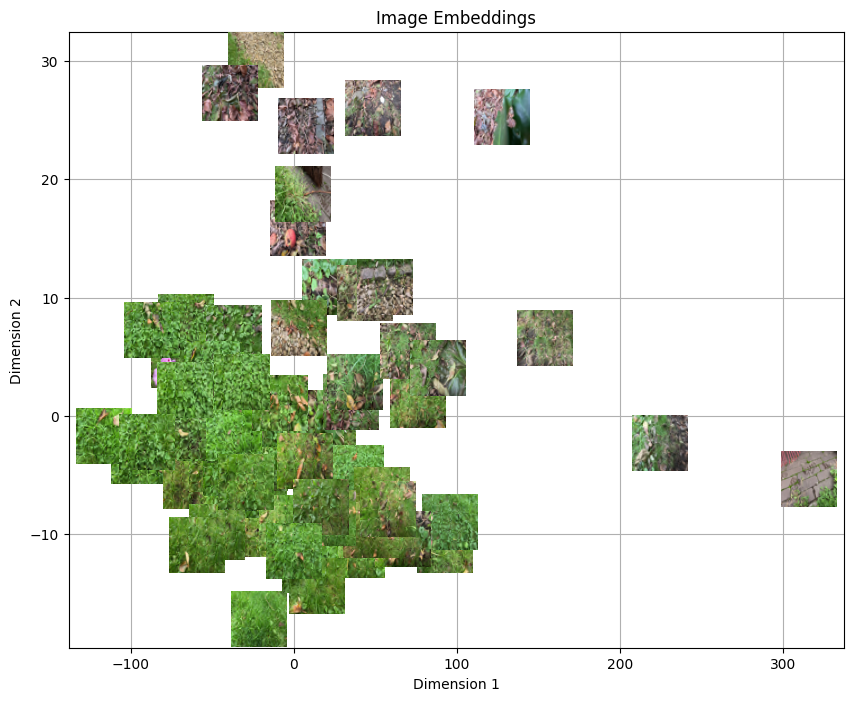

59


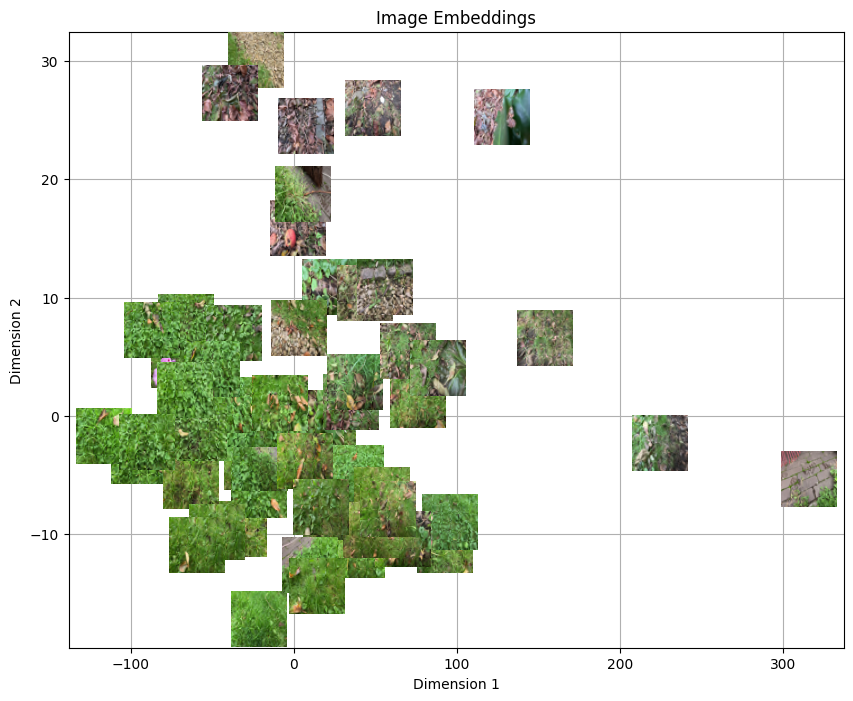

In [6]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(embeddings)

print(len(pca_results))
visualize_embeddings(pca_results)

print(len(pca_results[prune_mask]))
visualize_embeddings(pca_results, prune_mask)

84


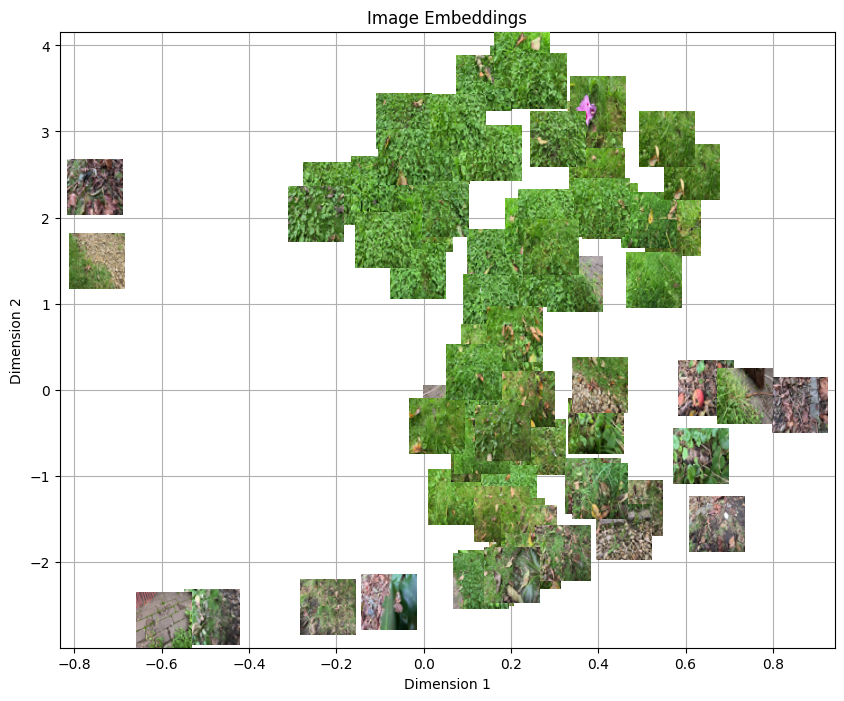

59


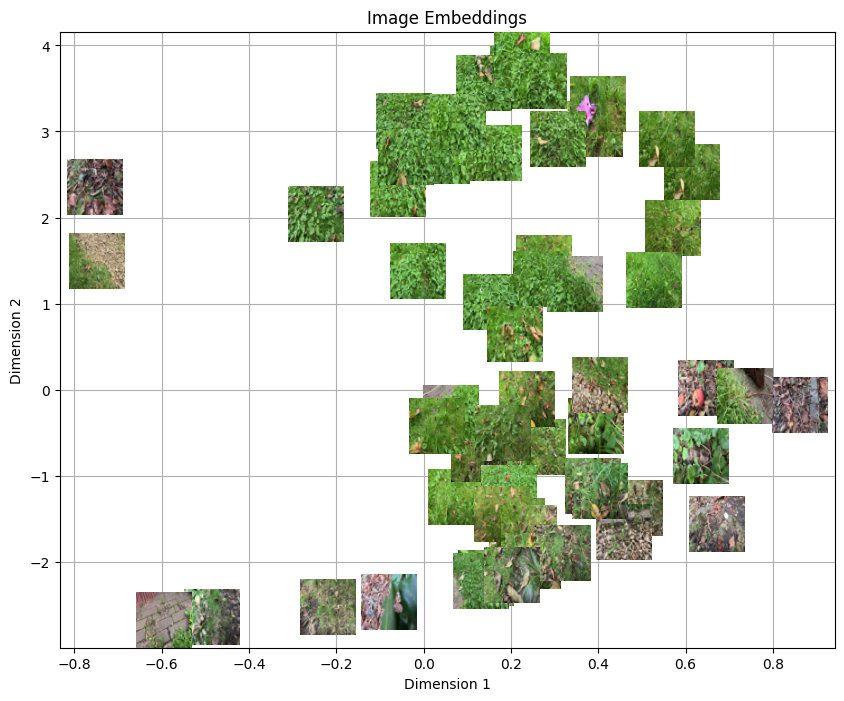

In [7]:
tsne = TSNE(n_components=2, perplexity=50)
tsne_results = tsne.fit_transform(embeddings)

print(len(tsne_results))
visualize_embeddings(tsne_results)

print(len(tsne_results[prune_mask]))
visualize_embeddings(tsne_results, prune_mask)

84


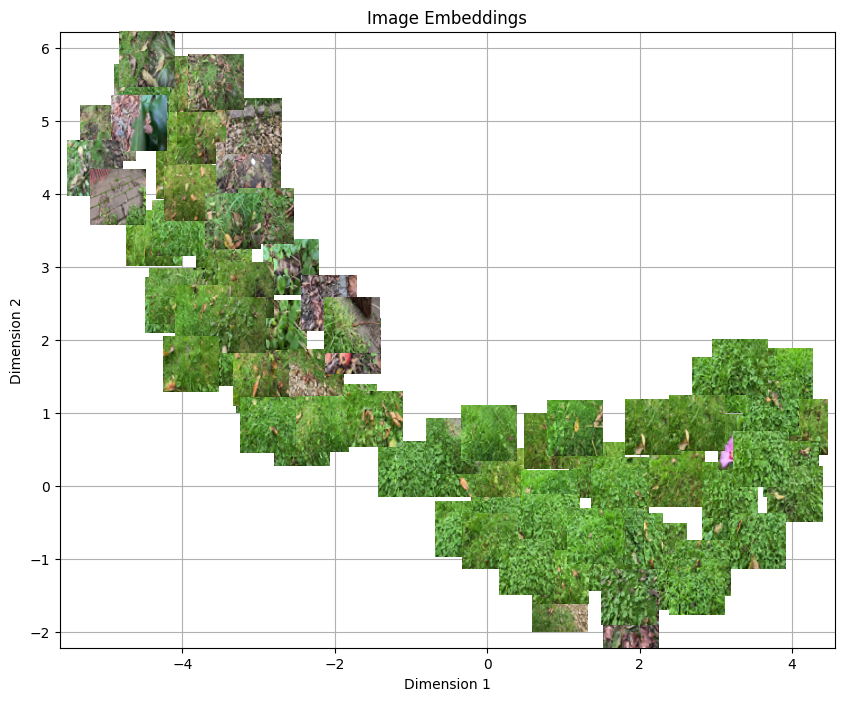

59


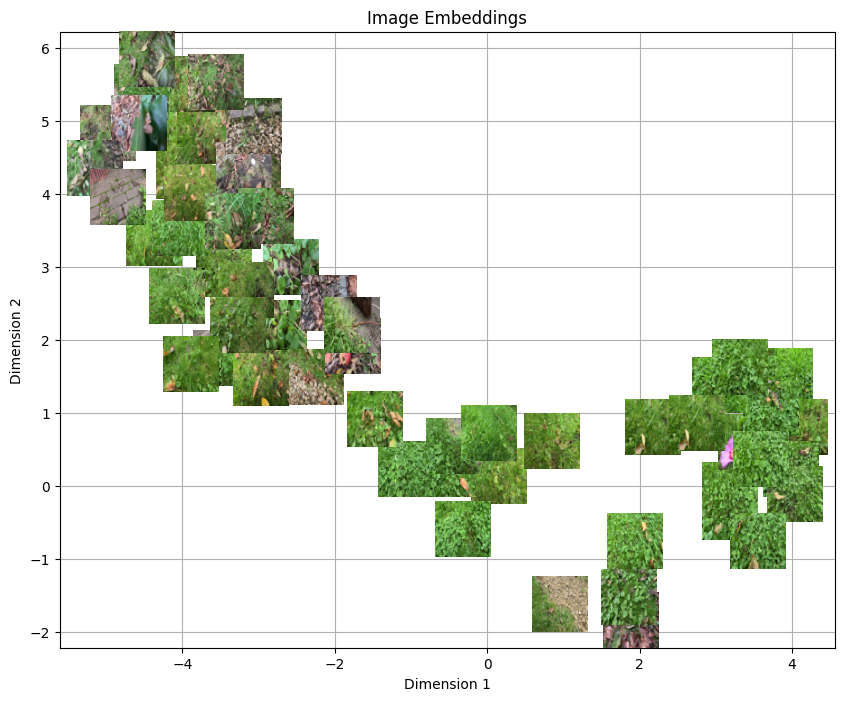

In [8]:
umap = UMAP(n_components=2, n_neighbors=50, min_dist=0.50)
umap_results = umap.fit_transform(embeddings)

print(len(umap_results))
visualize_embeddings(umap_results)

print(len(umap_results[prune_mask]))
visualize_embeddings(umap_results, prune_mask)